In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('shopping_trends.csv', encoding='latin-1')
print("Dataset loaded successfully.")

df.columns = [col.replace('_', '') for col in df.columns]
df.columns = df.columns.str.strip()

print('Columns: ', df.columns.tolist())

print(df.head(3))

Saving shopping_trends.csv to shopping_trends (3).csv
Dataset loaded successfully.
Columns:  ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Preferred Payment Method', 'Frequency of Purchases']
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   

        Location Size   Color  Season  Review Rating Subscription Status  \
0       Kentucky    L    Gray  Winter            3.1                 Yes   
1          Maine    L  Maroon  Winter            3.1                 Yes   
2  Massachusetts    S  Maroon  Spring            

In [15]:
# Data Cleaning

print("Missing Values")
print(df.isnull().sum())

print(df.dtypes)

print(f"Duplicate rows: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

# Clean columns names
df.columns = df.columns.str.strip().str.replace('', '_')
print('Cleaned Columns: ', df.columns.tolist())

Missing Values
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64
Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Review Rating               float64
Subscr

In [16]:
# Summary statistics
col = df.columns.tolist()
purchase_col = col[5]  # Purchase Amount is the 6th column
print("Using column:", purchase_col)

print(f"Mean:   ${df[purchase_col].mean():.2f}")
print(f"Median: ${df[purchase_col].median():.2f}")
print(f"Mode:   ${df[purchase_col].mode()[0]:.2f}")
print(f"Min:    ${df[purchase_col].min():.2f}")
print(f"Max:    ${df[purchase_col].max():.2f}")

Using column: _P_u_r_c_h_a_s_e_ _A_m_o_u_n_t_ _(_U_S_D_)_
Mean:   $59.76
Median: $60.00
Mode:   $32.00
Min:    $20.00
Max:    $100.00


In [20]:
# Feature Engineering

# Fix column names first
df.columns = [col.replace('_', '') for col in df.columns]
df.columns = df.columns.str.strip()

# Age segments
def age_group(age):
    if age < 25:
        return 'Young (18-24)'
    elif age < 35:
        return 'Young Adult (25-34)'
    elif age < 50:
        return 'Middle Age (35-49)'
    else:
        return 'Senior (50+)'

df['Age_Group'] = df['Age'].apply(age_group)

# Spending segments
def spending_segment(amount):
    if amount < 30:
        return 'Low Spender'
    elif amount < 60:
        return 'Medium Spender'
    else:
        return 'High Spender'

df['Spending_Segment'] = df['Purchase Amount (USD)'].apply(spending_segment)

# Loyalty score
df['Loyalty_Score'] = pd.cut(df['Previous Purchases'],
                              bins=[0, 5, 15, 30, 100],
                              labels=['New', 'Occasional', 'Regular', 'Loyal'])

print("Feature Engineering Done!")
print(df[['Age_Group', 'Spending_Segment', 'Loyalty_Score']].head())

Feature Engineering Done!
            Age_Group Spending_Segment Loyalty_Score
0        Senior (50+)   Medium Spender    Occasional
1       Young (18-24)     High Spender           New
2        Senior (50+)     High Spender       Regular
3       Young (18-24)     High Spender         Loyal
4  Middle Age (35-49)   Medium Spender         Loyal


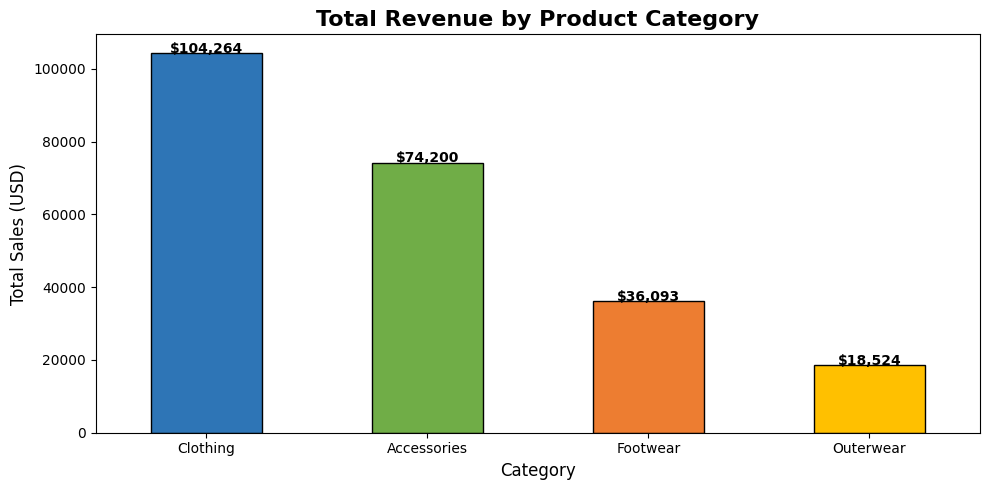

Chart 1 saved!


In [21]:
# Visualization-1 : Bar Chart
plt.figure(figsize=(10, 5))
cat_sales = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
colors = ['#2E75B6', '#70AD47', '#ED7D31', '#FFC000']
cat_sales.plot(kind='bar', color=colors, edgecolor='black')

for i, v in enumerate(cat_sales):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.title('Total Revenue by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart1_bar.png', dpi=150)
plt.show()
print("Chart 1 saved!")

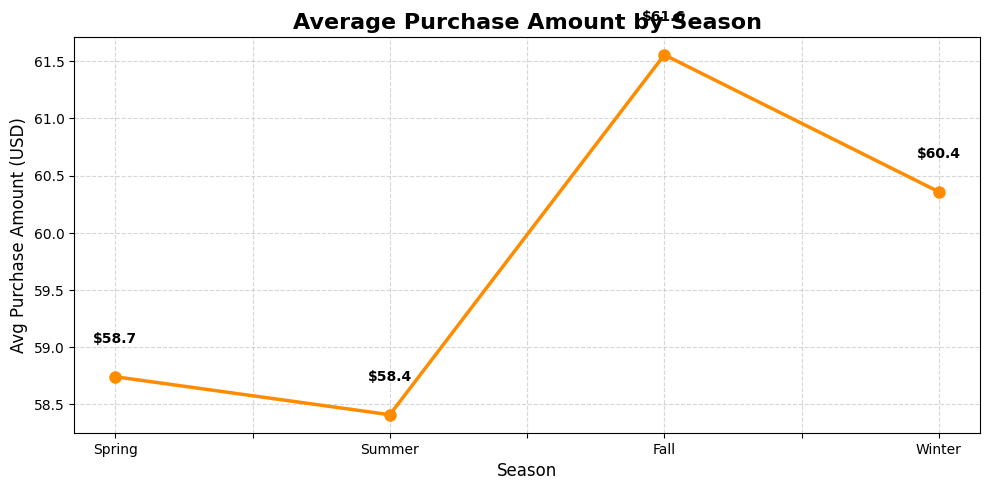

In [22]:
# Visualization-2 : Line Chart

plt.figure(figsize=(10, 5))
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_sales = df.groupby('Season')['Purchase Amount (USD)'].mean().reindex(season_order)
season_sales.plot(kind='line', marker='o', color='darkorange', linewidth=2.5, markersize=8)

for i, (season, val) in enumerate(season_sales.items()):
    plt.text(i, val + 0.3, f'${val:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.title('Average Purchase Amount by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Avg Purchase Amount (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart2_line.png', dpi=150)
plt.show()



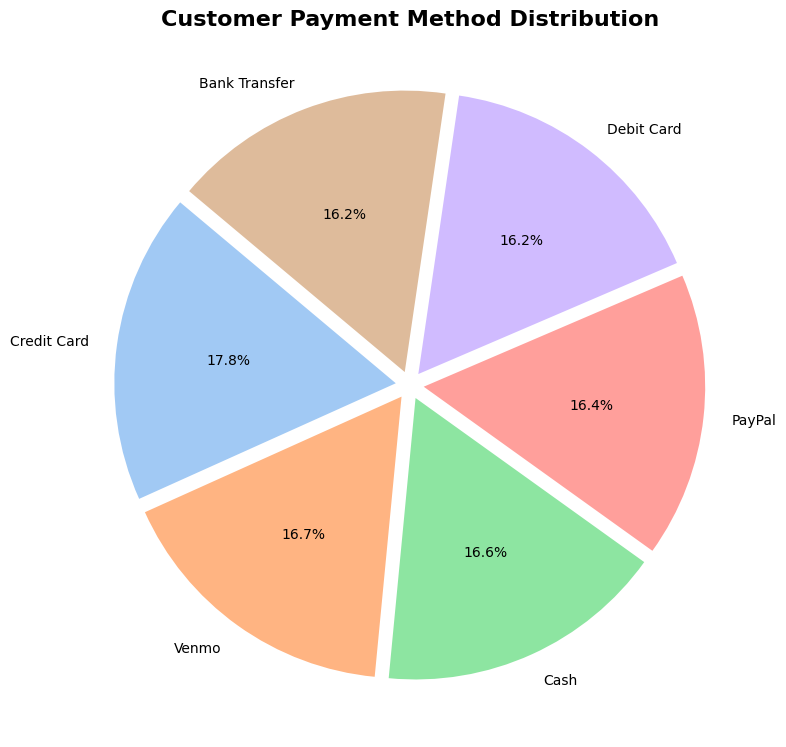

In [23]:
# Visualization-3 : Pie Chart

plt.figure(figsize=(8, 8))
payment_counts = df['Payment Method'].value_counts()
colors = sns.color_palette('pastel')
plt.pie(payment_counts, labels=payment_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=colors, explode=[0.05]*len(payment_counts))

plt.title('Customer Payment Method Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_pie.png', dpi=150)
plt.show()



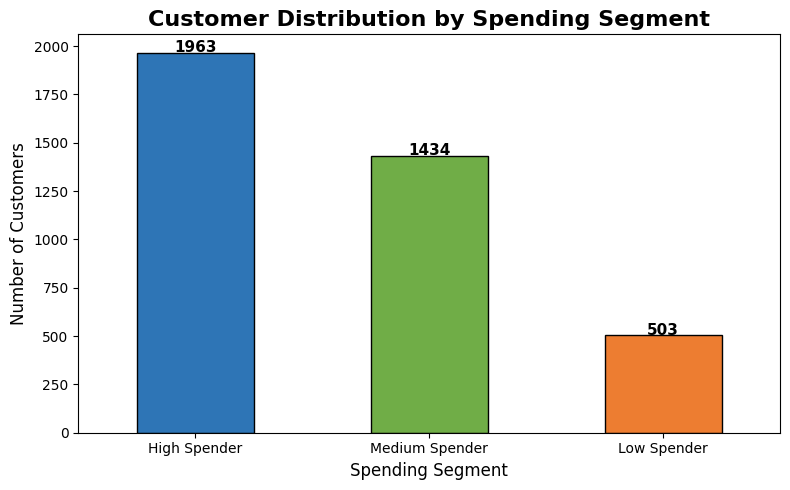

In [24]:
# Spending Segments
plt.figure(figsize=(8, 5))
segment_counts = df['Spending_Segment'].value_counts()
colors = ['#2E75B6', '#70AD47', '#ED7D31']
segment_counts.plot(kind='bar', color=colors, edgecolor='black')

for i, v in enumerate(segment_counts):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=11)

plt.title('Customer Distribution by Spending Segment', fontsize=16, fontweight='bold')
plt.xlabel('Spending Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart4_spending.png', dpi=150)
plt.show()



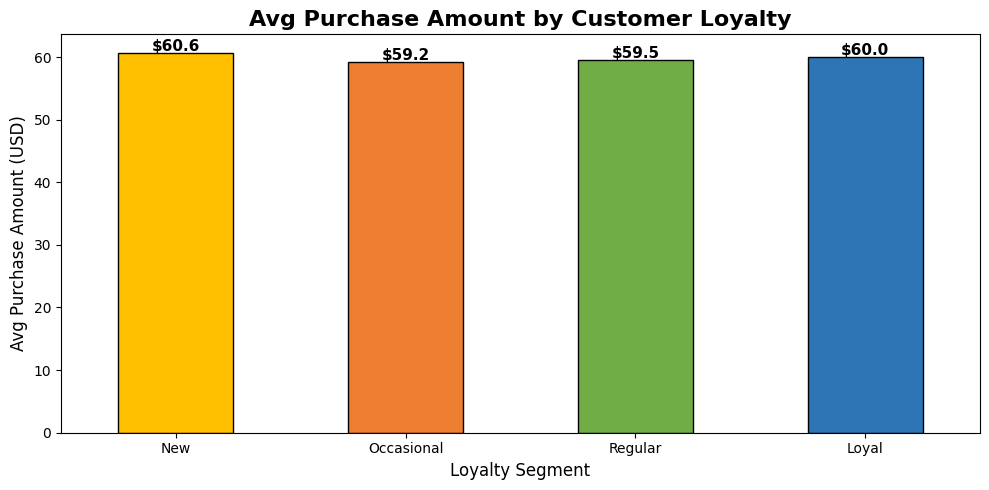

In [25]:
#  Loyalty Segments

plt.figure(figsize=(10, 5))
loyalty_spend = df.groupby('Loyalty_Score', observed=True)['Purchase Amount (USD)'].mean()
colors = ['#FFC000', '#ED7D31', '#70AD47', '#2E75B6']
loyalty_spend.plot(kind='bar', color=colors, edgecolor='black')

for i, v in enumerate(loyalty_spend):
    plt.text(i, v + 0.3, f'${v:.1f}', ha='center', fontweight='bold', fontsize=11)

plt.title('Avg Purchase Amount by Customer Loyalty', fontsize=16, fontweight='bold')
plt.xlabel('Loyalty Segment', fontsize=12)
plt.ylabel('Avg Purchase Amount (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart5_loyalty.png', dpi=150)
plt.show()


In [30]:
# Customer Stats

print(f"Total Customers:        {df['Customer ID'].nunique()}")
print(f"Avg Previous Purchases: {df['Previous Purchases'].mean():.1f}")
print(f"Avg Review Rating:      {df['Review Rating'].mean():.2f}")
print(f"Subscribed Customers:   {(df['Subscription Status'] == 'Yes').sum()}")

print(df['Frequency of Purchases'].value_counts())

print("\nDISCOUNT USAGE")
print(df['Discount Applied'].value_counts())

Total Customers:        3900
Avg Previous Purchases: 25.4
Avg Review Rating:      3.75
Subscribed Customers:   1053
Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

DISCOUNT USAGE
Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64


In [31]:
from google.colab import files
files.download('chart1_bar.png')
files.download('chart2_line.png')
files.download('chart3_pie.png')
files.download('chart4_spending.png')
files.download('chart5_loyalty.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>